# Following an Answer Through a Transformer

I built this notebook as a personal research lab for opening up one model behavior end to end. The concrete question is small on purpose: how does `gpt2-small` turn `The capital of France is Paris. The capital of Germany is` into the next-token prediction ` Berlin`?

## Research question
At what point does the model stop favoring the wrong continuation, which components push the right answer upward, and which of those components survive causal testing?

## What would count as evidence?
1. A temporal story: the target should rise across identifiable checkpoints rather than materializing from nowhere.
2. A directional story: attribution should narrow the candidate mechanism to a small set of layers or heads.
3. A causal story: patching should restore the behavior and ablation should damage it in the same neighborhood.

## Investigation plan
1. Follow the residual stream checkpoint by checkpoint.
2. Track how the target and rival tokens compete across pre-attention, post-attention, and post-MLP states.
3. Use direct logit attribution to form a concrete mechanistic hypothesis.
4. Inspect whether the candidate heads route information from plausible source tokens.
5. Test the hypothesis with activation patching and head ablation.
6. Close with what this style of analysis buys us when a model supports real workflows.

## Why this matters once a model is in use
Mechanistic analysis becomes useful when a model is part of a workflow that someone depends on. If I can localize where an answer forms, I have a better way to investigate regressions, explain changes to sponsors and reviewers, check whether a release altered a critical reasoning path, and give delivery, product, and risk teams something stronger than surface accuracy when they need confidence in a model-backed process.


## Environment and scope

I use `gpt2-small` on purpose. It is small enough to inspect end to end, but still rich enough to show residual-stream accumulation, competing candidates, direct logit attribution, attention patterns, activation patching, and head ablation in one notebook.

This notebook runs on CPU, although the causal sections are faster on GPU. If you are not already inside an environment with the project dependencies, run the bootstrap cell below first and then continue with the import cell.


In [1]:
# This bootstrap cell keeps the notebook runnable from a fresh VS Code kernel,
# a clean notebook server, or any other Python environment that does not yet
# have the repo dependencies installed.
import importlib.util
import subprocess
import sys
from pathlib import Path


def resolve_requirements_path():
    """Return the first requirements file path that matches the current working directory."""

    candidate_paths = [
        Path.cwd() / "requirements.txt",
        Path.cwd().parent / "requirements.txt",
    ]
    for candidate_path in candidate_paths:
        if candidate_path.exists():
            return candidate_path.resolve()
    raise FileNotFoundError("Could not find requirements.txt from the current notebook working directory.")


# We keep the mapping explicit so the setup message can explain which Python
# modules correspond to which pip distributions.
REQUIRED_MODULES = {
    "transformer_lens": "transformer-lens",
    "torch": "torch",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "IPython": "ipython",
}

REQUIREMENTS_PATH = resolve_requirements_path()
missing_distributions = [
    distribution_name
    for module_name, distribution_name in REQUIRED_MODULES.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_distributions:
    print("Installing missing notebook dependencies:", ", ".join(missing_distributions))
    print("Using requirements file:", REQUIREMENTS_PATH)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(REQUIREMENTS_PATH)])
    print("Dependency install finished. If your editor still shows stale imports, rerun this cell once.")
else:
    print("All required notebook dependencies are already available.")


Installing missing notebook dependencies: transformer-lens, torch, numpy, pandas, matplotlib
Using requirements file: C:\llm-mechanics-lab\requirements.txt
Dependency install finished. If your editor still shows stale imports, rerun this cell once.


In [2]:
# We import everything in one place so the rest of the notebook can focus on
# the analysis rather than on setup noise.
import contextlib
import importlib.metadata as md
import io
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import Markdown, display
from matplotlib.colors import TwoSlopeNorm

from transformer_lens import HookedTransformer, patching
from transformer_lens.utils import get_act_name

warnings.filterwarnings("ignore")

# We fix the random seeds so repeated runs are easier to compare.
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# We widen the dataframe display so inspection tables stay readable inline.
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda value: f"{value:0.4f}")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "gpt2-small"

# We use a short in-context probe because it gives this small model a clean
# answer to explain, which makes the later mechanistic story more credible.
PROMPT = "The capital of France is Paris. The capital of Germany is"
TARGET_ANSWER = " Berlin"
RIVAL_ANSWER = " Paris"

CLEAN_PROMPT = PROMPT
CORRUPTED_PROMPT = "The capital of France is Paris. The capital of France is"

TOP_K = 8
TOP_COMPONENTS = 12
HEADS_TO_VISUALIZE = 3
HEADS_TO_ABLATE = 6

COLORS = {
    "target": "#0F4C81",
    "rival": "#B55239",
    "accent": "#2F855A",
    "neutral": "#4A5568",
}

# We keep the plotting defaults in one place so every figure shares the same
# visual language and remains easy to compare.
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.18,
        "grid.linestyle": "--",
        "axes.titleweight": "semibold",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.frameon": False,
    }
)

print("Using device:", DEVICE)
print("torch:", torch.__version__)
print("transformer-lens:", md.version("transformer-lens"))


Using device: cpu
torch: 2.10.0+cpu
transformer-lens: 2.17.0


In [3]:
def display_takeaways(title, what, change, why, practice=None):
    """Render a short interpretation block after a major figure.

    We reuse the same structure throughout the notebook so someone scanning
    quickly can see what the figure is, what changed, and why the result
    matters before diving into the raw tables.
    """

    lines = [
        f"### {title}",
        f"- What we are looking at: {what}",
        f"- What changes here: {change}",
        f"- Why it matters: {why}",
    ]
    if practice:
        lines.append(f"- Why this matters in practice: {practice}")
    display(Markdown("\n".join(lines)))


def visible_token(token_str):
    """Make whitespace-heavy tokenizer strings easier to read in tables and labels."""

    return token_str.replace(" ", "[space]").replace("\n", "\\n")


def safe_to_single_token(model, token_str):
    """Convert a string to a single token ID and fail loudly if tokenization splits it."""

    token_ids = model.to_tokens(token_str, prepend_bos=False).squeeze(0).tolist()
    if len(token_ids) != 1:
        raise ValueError(
            f"Expected a single token for {token_str!r}, but got {len(token_ids)} tokens: {token_ids}"
        )
    return token_ids[0]


def token_id_to_str(model, token_id):
    """Decode one token ID to a printable string for notebook displays."""

    return model.to_string([token_id]).replace("\n", "\\n")


def final_token_logits(logits):
    """Return the logits that correspond to the final prediction position.

    TransformerLens sometimes returns tensors with a batch dimension and
    sometimes without it, depending on how the model run was requested.
    This helper gives the rest of the notebook one consistent interface.
    """

    if logits.ndim == 3:
        return logits[:, -1, :]
    if logits.ndim == 2:
        return logits[-1, :].unsqueeze(0)
    raise ValueError(f"Unexpected logits shape: {tuple(logits.shape)}")


def get_token_rank(logits_1d, token_id):
    """Rank a token by sorting the final-position logits from highest to lowest."""

    sorted_ids = torch.argsort(logits_1d, descending=True)
    rank = (sorted_ids == token_id).nonzero(as_tuple=False)
    return int(rank[0].item()) + 1


def make_metric_for_answer(answer_token, rival_token=None):
    """Create the metric used in the causal sections.

    We usually care about how much the target beats a rival token, because
    that gives us a cleaner measure of whether the model recovered the
    specific behavior we want.
    """

    def metric(logits):
        # We only score the final prediction position because that is the
        # position the notebook is trying to explain.
        last = final_token_logits(logits)
        answer_logit = last[:, answer_token]
        if rival_token is None:
            return answer_logit.mean()
        rival_logit = last[:, rival_token]
        return (answer_logit - rival_logit).mean()

    return metric


def top_predictions_table(model, logits_1d, k=8):
    """Return the top-k next-token predictions in a small inspection table."""

    probs = F.softmax(logits_1d, dim=-1)
    values, token_ids = torch.topk(probs, k=k)
    rows = []
    for rank, (probability, token_id) in enumerate(zip(values.tolist(), token_ids.tolist()), start=1):
        rows.append(
            {
                "rank": rank,
                "token": visible_token(token_id_to_str(model, token_id)),
                "token_id": token_id,
                "probability": probability,
            }
        )
    return pd.DataFrame(rows)


def parse_checkpoint_label(label):
    """Convert TransformerLens checkpoint labels into a friendlier display form."""

    label = str(label)
    if label in {"embed", "pos_embed"}:
        return {"layer": -1, "phase": label, "label_short": label.replace("_", " ")}
    if "_" not in label:
        return {"layer": None, "phase": label, "label_short": label}

    # We split labels such as `9_mid` into a layer number and a phase name
    # so later plots can show cleaner axis labels.
    layer_text, phase = label.split("_", 1)
    short_phase = {"pre": "pre", "mid": "attn", "post": "mlp"}.get(phase, phase)
    long_phase = {"pre": "pre-attn", "mid": "post-attn", "post": "post-mlp"}.get(phase, phase)
    try:
        layer_value = int(layer_text)
        label_short = f"L{layer_value} {short_phase}"
    except ValueError:
        layer_value = None
        label_short = label.replace("_", " ")
    return {"layer": layer_value, "phase": long_phase, "label_short": label_short}


def build_checkpoint_dataframe(model, checkpoint_labels, checkpoint_logits_last_pos, resid_last_pos, target_token, rival_token):
    """Assemble one dataframe that tracks the answer at every residual checkpoint."""

    probs = F.softmax(checkpoint_logits_last_pos, dim=-1)
    rows = []
    for checkpoint_idx, label in enumerate(checkpoint_labels):
        meta = parse_checkpoint_label(label)
        top_id = int(probs[checkpoint_idx].argmax().item())
        rows.append(
            {
                "checkpoint_idx": checkpoint_idx,
                "label": str(label),
                "label_short": meta["label_short"],
                "layer": meta["layer"],
                "phase": meta["phase"],
                "target_token": visible_token(token_id_to_str(model, target_token)),
                "rival_token": visible_token(token_id_to_str(model, rival_token)),
                "target_prob": probs[checkpoint_idx, target_token].item(),
                "rival_prob": probs[checkpoint_idx, rival_token].item(),
                "logit_diff": (
                    checkpoint_logits_last_pos[checkpoint_idx, target_token]
                    - checkpoint_logits_last_pos[checkpoint_idx, rival_token]
                ).item(),
                "target_rank": get_token_rank(checkpoint_logits_last_pos[checkpoint_idx], target_token),
                "rival_rank": get_token_rank(checkpoint_logits_last_pos[checkpoint_idx], rival_token),
                "top_prediction": visible_token(token_id_to_str(model, top_id)),
                "residual_norm": resid_last_pos[checkpoint_idx].norm().item(),
            }
        )
    return pd.DataFrame(rows)


In [4]:
def choose_candidate_token_ids(checkpoint_logits_last_pos, target_token, rival_token, max_tokens=7):
    """Pick a compact set of candidate tokens to track through the forward pass.

    We force the target and rival into the set and then add tokens that look
    competitive at several anchor checkpoints. This keeps the heatmap readable
    without hiding the main alternatives.
    """

    probs = F.softmax(checkpoint_logits_last_pos, dim=-1)
    anchor_points = sorted(
        {
            0,
            len(checkpoint_logits_last_pos) // 4,
            len(checkpoint_logits_last_pos) // 2,
            (3 * len(checkpoint_logits_last_pos)) // 4,
            len(checkpoint_logits_last_pos) - 1,
        }
    )
    candidate_ids = {target_token, rival_token}
    for anchor in anchor_points:
        candidate_ids.update(torch.topk(probs[anchor], k=4).indices.tolist())

    other_ids = sorted(
        [token_id for token_id in candidate_ids if token_id not in {target_token, rival_token}],
        key=lambda token_id: probs[:, token_id].max().item(),
        reverse=True,
    )
    return ([target_token, rival_token] + other_ids)[:max_tokens]


def build_candidate_matrix(model, checkpoint_logits_last_pos, candidate_token_ids):
    """Build the token-by-checkpoint matrix used in the competition heatmap."""

    probs = F.softmax(checkpoint_logits_last_pos, dim=-1).detach().cpu().numpy()
    token_labels = [visible_token(token_id_to_str(model, token_id)) for token_id in candidate_token_ids]
    matrix = np.vstack([probs[:, token_id] for token_id in candidate_token_ids])
    return token_labels, matrix


def extract_last_position_scores(tensor):
    """Collapse a component stack down to one score per component at the final position."""

    scores = tensor.detach().cpu().squeeze()
    if scores.ndim == 1:
        return scores
    scores = scores[..., -1]
    if scores.ndim > 1:
        scores = scores.reshape(scores.shape[0], -1).sum(dim=-1)
    return scores


def attrs_to_df(labels, attrs):
    """Convert direct-logit-attribution outputs into a sorted dataframe."""

    scores = extract_last_position_scores(attrs).numpy()
    return pd.DataFrame({"component": list(labels), "logit_attr": scores}).sort_values(
        "logit_attr",
        ascending=False,
    ).reset_index(drop=True)


def head_attrs_to_df(model, attrs):
    """Reshape head-level attribution scores into a layer/head table."""

    scores = extract_last_position_scores(attrs).numpy().reshape(model.cfg.n_layers, model.cfg.n_heads)
    rows = []
    for layer in range(model.cfg.n_layers):
        for head in range(model.cfg.n_heads):
            rows.append(
                {
                    "layer": layer,
                    "head": head,
                    "label": f"L{layer}H{head}",
                    "logit_attr": scores[layer, head],
                }
            )
    return pd.DataFrame(rows).sort_values("logit_attr", ascending=False).reset_index(drop=True)


def normalize_patch_scores(scores, clean_score, corrupted_score):
    """Scale raw patch scores so 0 means corrupted behavior and 1 means clean recovery."""

    denominator = clean_score - corrupted_score
    if abs(denominator) < 1e-6:
        return scores * 0.0
    return (scores - corrupted_score) / denominator


def head_scores_to_df(head_scores):
    """Convert a layer-by-head score tensor into a sortable dataframe."""

    rows = []
    for layer in range(head_scores.shape[0]):
        for head in range(head_scores.shape[1]):
            rows.append(
                {
                    "layer": layer,
                    "head": head,
                    "label": f"L{layer}H{head}",
                    "score": head_scores[layer, head].item(),
                }
            )
    return pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)


def zero_head_hook(head_idx):
    """Return a hook that zeros one attention head output tensor during ablation."""

    def hook_fn(z, hook):
        # We clone before editing so we do not mutate the original activation.
        z = z.clone()
        z[:, :, head_idx, :] = 0.0
        return z

    return hook_fn


def ablate_single_head_and_score(model, tokens, layer, head, metric_fn, baseline_score):
    """Ablate one head on the clean prompt and measure how much the metric drops."""

    with torch.inference_mode():
        ablated_logits = model.run_with_hooks(
            tokens,
            fwd_hooks=[(get_act_name("z", layer), zero_head_hook(head))],
        )
    ablated_score = metric_fn(ablated_logits).item()
    return {
        "layer": layer,
        "head": head,
        "label": f"L{layer}H{head}",
        "baseline_score": baseline_score,
        "ablated_score": ablated_score,
        "delta": ablated_score - baseline_score,
    }


In [5]:
def plot_emergence_overview(checkpoint_df):
    """Plot both the probability race and the target-minus-rival logit margin."""

    x = checkpoint_df["checkpoint_idx"]
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(16, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1]},
        constrained_layout=True,
    )

    # The top panel answers the intuitive question: which token is winning?
    axes[0].plot(
        x,
        checkpoint_df["target_prob"],
        marker="o",
        color=COLORS["target"],
        linewidth=2,
        label=checkpoint_df["target_token"].iloc[0],
    )
    axes[0].plot(
        x,
        checkpoint_df["rival_prob"],
        marker="o",
        color=COLORS["rival"],
        linewidth=2,
        label=checkpoint_df["rival_token"].iloc[0],
    )
    axes[0].set_title("When does the answer overtake the rival?")
    axes[0].set_ylabel("Probability at final position")
    axes[0].legend(ncol=2)

    # The bottom panel shows the margin directly, which is useful when both
    # probabilities are still numerically small but one token is gaining ground.
    axes[1].plot(
        x,
        checkpoint_df["logit_diff"],
        marker="o",
        color=COLORS["accent"],
        linewidth=2,
    )
    axes[1].axhline(0, color=COLORS["neutral"], linestyle="--", linewidth=1)
    axes[1].set_ylabel("Target - rival logit")
    axes[1].set_xlabel("Residual checkpoint")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(checkpoint_df["label_short"], rotation=90)
    return fig


def plot_candidate_heatmap(token_labels, matrix, checkpoint_labels):
    """Plot a compact heatmap of how several plausible tokens evolve over time."""

    fig, ax = plt.subplots(figsize=(16, 5), constrained_layout=True)
    image = ax.imshow(matrix, aspect="auto", cmap="YlGnBu")
    ax.set_title("How competing candidates rise and fall across checkpoints")
    ax.set_xlabel("Residual checkpoint")
    ax.set_ylabel("Candidate token")
    ax.set_xticks(np.arange(len(checkpoint_labels)))
    ax.set_xticklabels(checkpoint_labels, rotation=90)
    ax.set_yticks(np.arange(len(token_labels)))
    ax.set_yticklabels(token_labels)
    fig.colorbar(image, ax=ax, label="Probability at final position")
    return fig


def plot_residual_norm(checkpoint_df):
    """Plot how the residual stream norm changes across the same checkpoints."""

    x = checkpoint_df["checkpoint_idx"]
    fig, ax = plt.subplots(figsize=(16, 4), constrained_layout=True)
    ax.plot(x, checkpoint_df["residual_norm"], marker="o", color=COLORS["neutral"], linewidth=2)
    ax.set_title("Residual stream norm keeps changing across the same checkpoints")
    ax.set_xlabel("Residual checkpoint")
    ax.set_ylabel("Residual L2 norm")
    ax.set_xticks(x)
    ax.set_xticklabels(checkpoint_df["label_short"], rotation=90)
    return fig


def plot_component_attribution(dla_df, target_answer, top_n=12):
    """Plot the largest direct-logit-attribution contributors for the target token."""

    plot_df = dla_df.head(top_n).sort_values("logit_attr")
    colors = [COLORS["target"] if value >= 0 else COLORS["rival"] for value in plot_df["logit_attr"]]
    fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
    ax.barh(plot_df["component"], plot_df["logit_attr"], color=colors)
    ax.axvline(0, color=COLORS["neutral"], linewidth=1)
    ax.set_title(f"Which components push the logit for {visible_token(target_answer)}?")
    ax.set_xlabel("Direct logit attribution at the final position")
    ax.set_ylabel("Residual component")
    return fig


def plot_attention_heads(cache, head_df, str_tokens):
    """Plot the attention patterns for a small set of candidate heads."""

    heads = list(head_df[["layer", "head", "logit_attr"]].itertuples(index=False, name=None))
    fig, axes = plt.subplots(1, len(heads), figsize=(5 * len(heads), 4.5), constrained_layout=True)
    if len(heads) == 1:
        axes = [axes]

    tick_labels = [visible_token(token) for token in str_tokens]
    for ax, (layer, head, score) in zip(axes, heads):
        pattern = cache["pattern", layer][head].detach().cpu().numpy()
        image = ax.imshow(pattern, cmap="Blues")
        ax.set_title(f"L{layer}H{head}\nhead DLA={score:0.3f}")
        ax.set_xticks(np.arange(len(tick_labels)))
        ax.set_xticklabels(tick_labels, rotation=45, ha="right")
        ax.set_yticks(np.arange(len(tick_labels)))
        ax.set_yticklabels(tick_labels)
        ax.set_xlabel("Source position")
        ax.set_ylabel("Destination position")
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    return fig


def plot_block_patching(block_scores, token_labels):
    """Plot normalized block-level recovery scores for the corrupted prompt."""

    patch_labels = ["resid_pre", "attn_out", "mlp_out"]
    vmin = min(float(block_scores.min().item()), -0.25)
    vmax = max(float(block_scores.max().item()), 1.0)
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)
    for axis, patch_label, values in zip(axes, patch_labels, block_scores):
        image = axis.imshow(values.detach().cpu().numpy(), aspect="auto", cmap="RdYlBu_r", norm=norm)
        axis.set_title(patch_label)
        axis.set_xlabel("Position")
        axis.set_ylabel("Layer")
        axis.set_xticks(np.arange(len(token_labels)))
        axis.set_xticklabels(token_labels, rotation=45, ha="right")
        axis.set_yticks(np.arange(values.shape[0]))
        fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    fig.suptitle("How much clean information is restored when we patch each block output?")
    return fig


def plot_head_patching(head_scores):
    """Plot normalized recovery scores for each attention head output."""

    vmin = min(float(head_scores.min().item()), -0.25)
    vmax = max(float(head_scores.max().item()), 1.0)
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
    fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
    image = ax.imshow(head_scores.detach().cpu().numpy(), aspect="auto", cmap="RdYlBu_r", norm=norm)
    ax.set_title("Which attention heads restore the clean answer when we patch their outputs?")
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
    ax.set_xticks(np.arange(head_scores.shape[1]))
    ax.set_yticks(np.arange(head_scores.shape[0]))
    fig.colorbar(image, ax=ax, label="Normalized recovery")
    return fig


def plot_ablation_effects(ablation_df):
    """Plot how much the clean metric moves when we ablate candidate heads."""

    plot_df = ablation_df.sort_values("delta")
    colors = [COLORS["rival"] if value < 0 else COLORS["accent"] for value in plot_df["delta"]]
    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    ax.barh(plot_df["label"], plot_df["delta"], color=colors)
    ax.axvline(0, color=COLORS["neutral"], linewidth=1)
    ax.set_title("How much does the target-vs-rival score move when we ablate a candidate head?")
    ax.set_xlabel("Delta after ablation")
    ax.set_ylabel("Head")
    return fig


## 1. What exactly are we trying to explain?

I anchor the notebook around one short in-context capital probe. For `gpt2-small`, the extra example sentence creates a cleaner behavior than the bare prompt alone, which makes the internal story easier to inspect without changing the overall task. Once the probe is set, we can ask a narrow question: where does ` Berlin` start to overtake its competitors, and what inside the network makes that happen?


In [6]:
# We load the model once and keep attention results available because later
# sections will inspect head outputs, patch them, and ablate them.
model = HookedTransformer.from_pretrained(MODEL_NAME, device=DEVICE)
model.set_use_attn_result(True)

# We tokenize the prompt once so every downstream cell refers to the same input.
tokens = model.to_tokens(PROMPT)
str_tokens = model.to_str_tokens(PROMPT)

# We resolve the target and rival strings to token IDs up front so every later
# comparison uses the exact same tokenizer boundary.
target_token_id = safe_to_single_token(model, TARGET_ANSWER)
rival_token_id = safe_to_single_token(model, RIVAL_ANSWER)

experiment_df = pd.DataFrame(
    [
        {"field": "model", "value": MODEL_NAME},
        {"field": "prompt", "value": PROMPT},
        {"field": "string tokens", "value": str(str_tokens)},
        {"field": "target token", "value": f"{visible_token(TARGET_ANSWER)} -> {target_token_id}"},
        {"field": "rival token", "value": f"{visible_token(RIVAL_ANSWER)} -> {rival_token_id}"},
    ]
)
display(experiment_df)


Loaded pretrained model gpt2-small into HookedTransformer


,field,value
0,model,gpt2-small
1,prompt,The capital of France is Paris. The capital of...
2,string tokens,"['<|endoftext|>', 'The', ' capital', ' of', ' ..."
3,target token,[space]Berlin -> 11307
4,rival token,[space]Paris -> 6342


In [7]:
# We run the prompt once and keep the activation cache because almost every
# later analysis cell depends on reusing this forward pass.
with torch.no_grad():
    logits, cache = model.run_with_cache(tokens, remove_batch_dim=True)

# We inspect the final next-token distribution before decomposing anything so
# we know the behavior we are about to explain is real.
final_logits = final_token_logits(logits).squeeze(0)
final_predictions_df = top_predictions_table(model, final_logits, k=TOP_K)
display(final_predictions_df)

target_rank = get_token_rank(final_logits, target_token_id)
rival_rank = get_token_rank(final_logits, rival_token_id)
print(f"Final rank of {visible_token(TARGET_ANSWER)}: {target_rank}")
print(f"Final rank of {visible_token(RIVAL_ANSWER)}: {rival_rank}")


Final rank of [space]Berlin: 1
Final rank of [space]Paris: 14


,rank,token,token_id,probability
0,1,[space]Berlin,11307,0.3219
1,2,[space]Frankfurt,31970,0.1599
2,3,[space]Munich,22418,0.0857
3,4,[space]Dresden,46993,0.0749
4,5,[space]Hamburg,32526,0.0700
5,6,[space]Cologne,34923,0.0521
6,7,[space]Sch,3059,0.0103
7,8,[space]Vienna,23825,0.0093


In [8]:
# We interpret the final prediction before opening up the internal states.
display_takeaways(
    title="Why start with the final prediction?",
    what="The model's next-token distribution after the full forward pass.",
    change=(f"For this prompt, {visible_token(TARGET_ANSWER)} finishes at rank {target_rank}, while {visible_token(RIVAL_ANSWER)} finishes at rank {rival_rank}."),
    why="Before we decompose anything, we want to verify that the model gives us a clean behavior worth explaining.",
    practice="This is the equivalent of validating the business outcome before spending time on root-cause analysis. If the top-line behavior is not real, the mechanistic story is not useful.",
)


### Why start with the final prediction?
- What we are looking at: The model's next-token distribution after the full forward pass.
- What changes here: For this prompt, [space]Berlin finishes at rank 1, while [space]Paris finishes at rank 14.
- Why it matters: Before we decompose anything, we want to verify that the model gives us a clean behavior worth explaining.
- Why this matters in practice: This is the equivalent of validating the business outcome before spending time on root-cause analysis. If the top-line behavior is not real, the mechanistic story is not useful.

## 2. Does the answer appear all at once?

We start with the simplest possible test. If the answer only snaps into place at the very end, the later causal sections should probably focus on the final blocks. If it emerges gradually, we should expect a distributed story where different checkpoints reshape the candidate set over time.


In [9]:
# We ask TransformerLens for the accumulated residual stream at every
# checkpoint, including the mid-layer state after attention but before the MLP.
accum_resid, checkpoint_labels = cache.accumulated_resid(
    layer=-1,
    incl_mid=True,
    return_labels=True,
)

# We only care about the final token position because that is where the next
# answer token is predicted.
resid_last_pos = accum_resid[:, -1, :]

# We pass each checkpoint through the final layer norm and unembedding so each
# residual state becomes an interpretable next-token distribution.
resid_normed = model.ln_final(accum_resid)
checkpoint_logits = model.unembed(resid_normed)
checkpoint_logits_last_pos = checkpoint_logits[:, -1, :]

checkpoint_df = build_checkpoint_dataframe(
    model=model,
    checkpoint_labels=checkpoint_labels,
    checkpoint_logits_last_pos=checkpoint_logits_last_pos,
    resid_last_pos=resid_last_pos,
    target_token=target_token_id,
    rival_token=rival_token_id,
)

# We pick a small set of competitors so the later heatmap stays readable.
candidate_token_ids = choose_candidate_token_ids(
    checkpoint_logits_last_pos,
    target_token=target_token_id,
    rival_token=rival_token_id,
    max_tokens=7,
)
candidate_labels, candidate_matrix = build_candidate_matrix(
    model,
    checkpoint_logits_last_pos,
    candidate_token_ids,
)

display(checkpoint_df.head(12))


,checkpoint_idx,label,label_short,layer,phase,target_token,rival_token,target_prob,rival_prob,logit_diff,target_rank,rival_rank,top_prediction,residual_norm
0,0,0_pre,L0 pre,0.0000,pre-attn,[space]Berlin,[space]Paris,0.0000,0.0000,0.1762,26717,27603,[space]destro,4.6034
1,1,0_mid,L0 attn,0.0000,post-attn,[space]Berlin,[space]Paris,0.0000,0.0000,0.0471,15575,15850,[space]very,28.3381
2,2,1_pre,L1 pre,1.0000,pre-attn,[space]Berlin,[space]Paris,0.0000,0.0000,1.4875,7778,15549,[space]not,54.5633
3,3,1_mid,L1 attn,1.0000,post-attn,[space]Berlin,[space]Paris,0.0000,0.0000,2.1030,4211,12001,[space]now,53.9710
4,4,2_pre,L2 pre,2.0000,pre-attn,[space]Berlin,[space]Paris,0.0000,0.0000,2.2996,4972,14682,[space]now,55.9073
5,5,2_mid,L2 attn,2.0000,post-attn,[space]Berlin,[space]Paris,0.0000,0.0000,2.3997,3072,10534,[space]now,58.3127
6,6,3_pre,L3 pre,3.0000,pre-attn,[space]Berlin,[space]Paris,0.0000,0.0000,2.5244,4114,13902,[space]now,57.6643
7,7,3_mid,L3 attn,3.0000,post-attn,[space]Berlin,[space]Paris,0.0000,0.0000,3.2047,2341,11641,[space]also,59.6797
8,8,4_pre,L4 pre,4.0000,pre-attn,[space]Berlin,[space]Paris,0.0000,0.0000,2.2691,3076,9244,[space]also,60.4477
9,9,4_mid,L4 attn,4.0000,post-attn,[space]Berlin,[space]Paris,0.0000,0.0000,2.1128,1400,4400,[space]also,63.3420


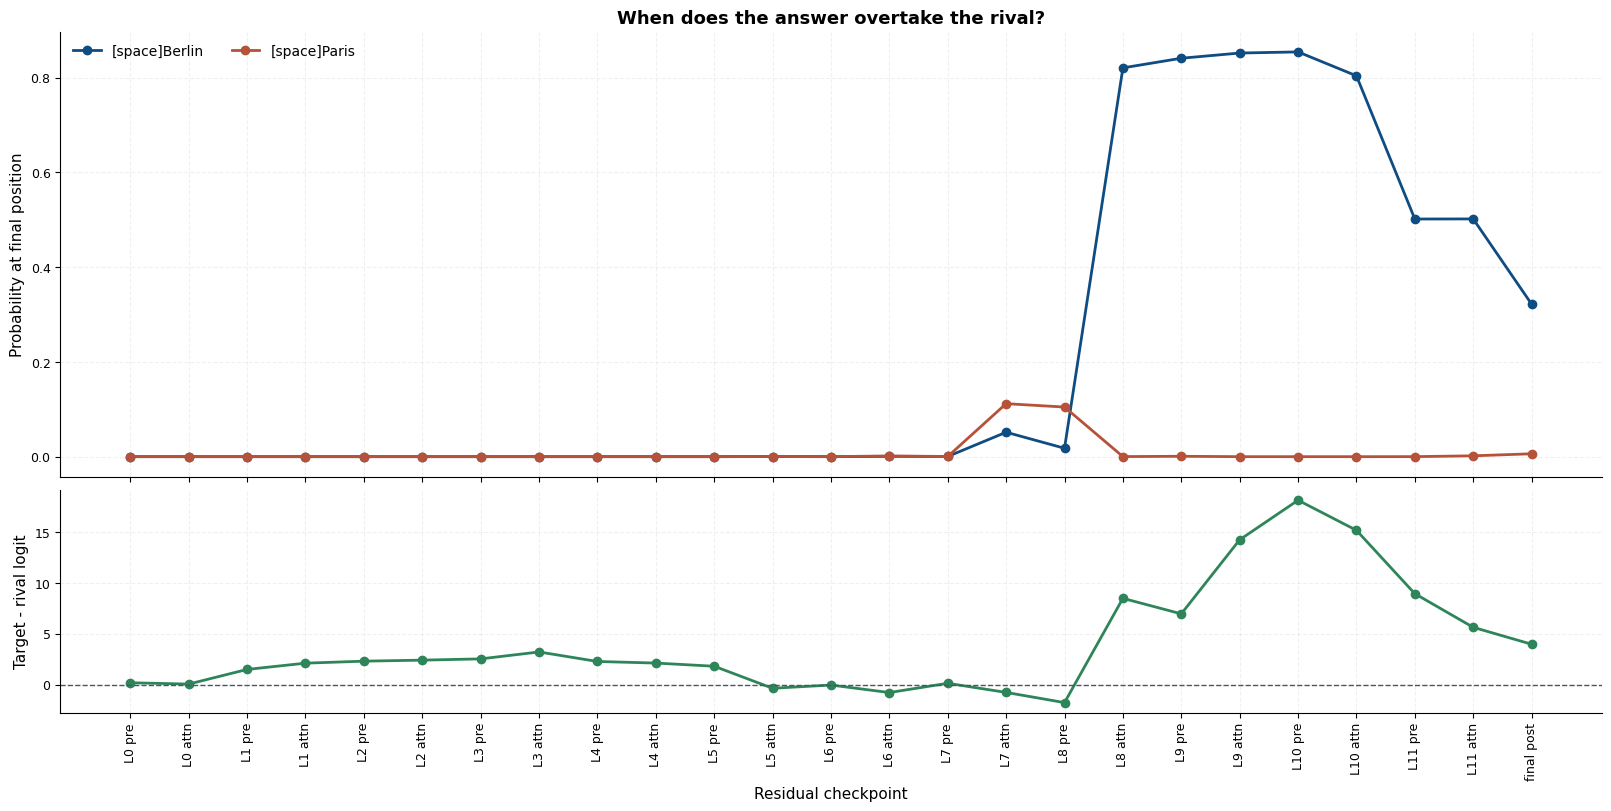

In [10]:
# We plot both the probability race and the target-minus-rival margin together
# because the two views answer slightly different questions.
plot_emergence_overview(checkpoint_df)
plt.show()


In [11]:
# We summarize the emergence plot in plain language so the notebook keeps the
# story visible between code cells.
target_beats_rival = checkpoint_df.loc[checkpoint_df["logit_diff"] > 0, "label_short"]
target_reaches_top = checkpoint_df.loc[checkpoint_df["target_rank"] == 1, "label_short"]
first_target_beats_rival = target_beats_rival.iloc[0] if not target_beats_rival.empty else "never"
first_target_top = target_reaches_top.iloc[0] if not target_reaches_top.empty else "never"
opening_top = checkpoint_df.iloc[0]["top_prediction"]

display_takeaways(
    title="Reading the emergence plot",
    what="The target probability, rival probability, and target-minus-rival logit gap at each residual checkpoint.",
    change=(f"The checkpoint sequence opens with {opening_top} as the top candidate, {visible_token(TARGET_ANSWER)} first beats {visible_token(RIVAL_ANSWER)} at {first_target_beats_rival}, and it first becomes rank 1 at {first_target_top}."),
    why="This shows that the answer is assembled over time rather than appearing in one last-step jump.",
    practice="When a model starts behaving differently after a release, this kind of timeline helps a delivery team narrow the search to a specific stage of the forward pass instead of relying on a vague before-versus-after comparison.",
)


### Reading the emergence plot
- What we are looking at: The target probability, rival probability, and target-minus-rival logit gap at each residual checkpoint.
- What changes here: The checkpoint sequence opens with [space]destro as the top candidate, [space]Berlin first beats [space]Paris at L0 pre, and it first becomes rank 1 at L8 attn.
- Why it matters: This shows that the answer is assembled over time rather than appearing in one last-step jump.
- Why this matters in practice: When a model starts behaving differently after a release, this kind of timeline helps a delivery team narrow the search to a specific stage of the forward pass instead of relying on a vague before-versus-after comparison.

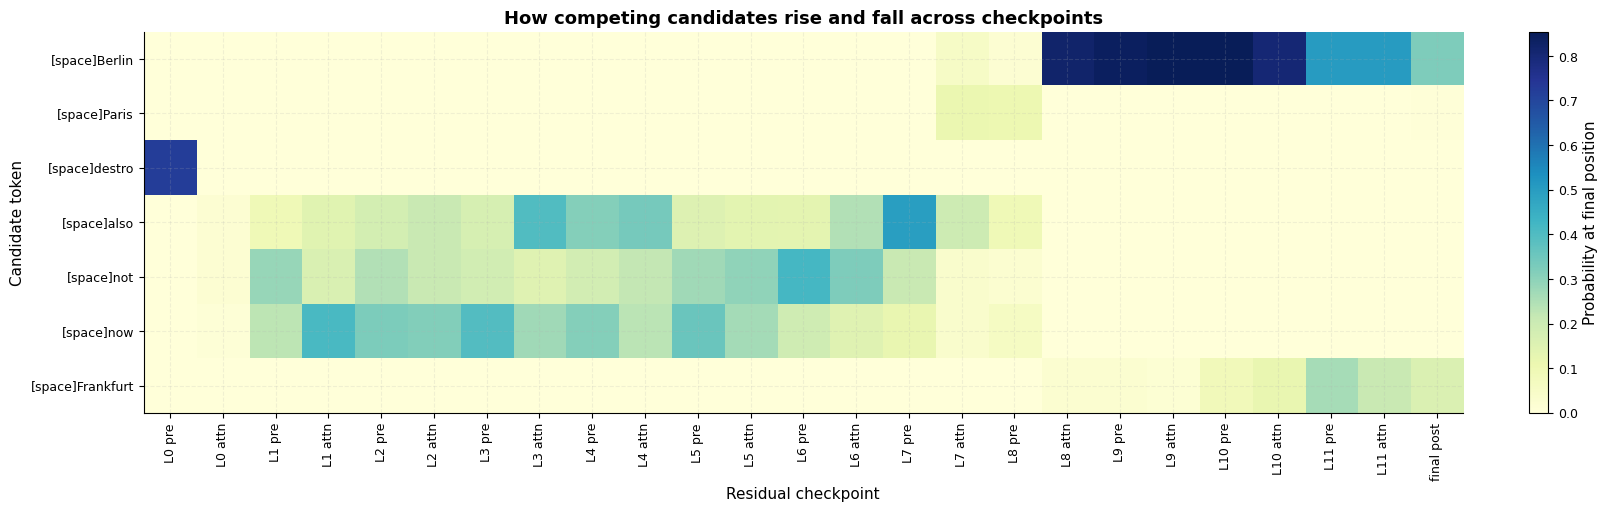

In [12]:
# We plot a compact competition view so the target is judged against plausible
# alternatives rather than in isolation.
plot_candidate_heatmap(candidate_labels, candidate_matrix, checkpoint_df["label_short"].tolist())
plt.show()


In [13]:
# We highlight the strongest non-target competitor so the interpretation does
# not hand-wave over the most important alternative answer.
strongest_competitor_idx = int(np.argmax(candidate_matrix[1:].max(axis=1))) + 1 if candidate_matrix.shape[0] > 1 else 0
strongest_competitor = candidate_labels[strongest_competitor_idx]
strongest_competitor_peak = candidate_matrix[strongest_competitor_idx].max()
target_peak = candidate_matrix[0].max()

display_takeaways(
    title="Reading the competition heatmap",
    what="A compact view of how a small set of plausible tokens rise and fall over the same checkpoints.",
    change=(f"The strongest non-target candidate in this set is {strongest_competitor}, which peaks at probability {strongest_competitor_peak:0.3f}, while {candidate_labels[0]} eventually peaks at {target_peak:0.3f}."),
    why="A strong mechanistic story should explain why the winning answer beat the most relevant alternatives.",
    practice="This helps distinguish a model that is confidently right from a model that only narrowly beats the wrong answer, which matters when outputs support client-facing or review-heavy work.",
)


### Reading the competition heatmap
- What we are looking at: A compact view of how a small set of plausible tokens rise and fall over the same checkpoints.
- What changes here: The strongest non-target candidate in this set is [space]destro, which peaks at probability 0.722, while [space]Berlin eventually peaks at 0.854.
- Why it matters: A strong mechanistic story should explain why the winning answer beat the most relevant alternatives.
- Why this matters in practice: This helps distinguish a model that is confidently right from a model that only narrowly beats the wrong answer, which matters when outputs support client-facing or review-heavy work.

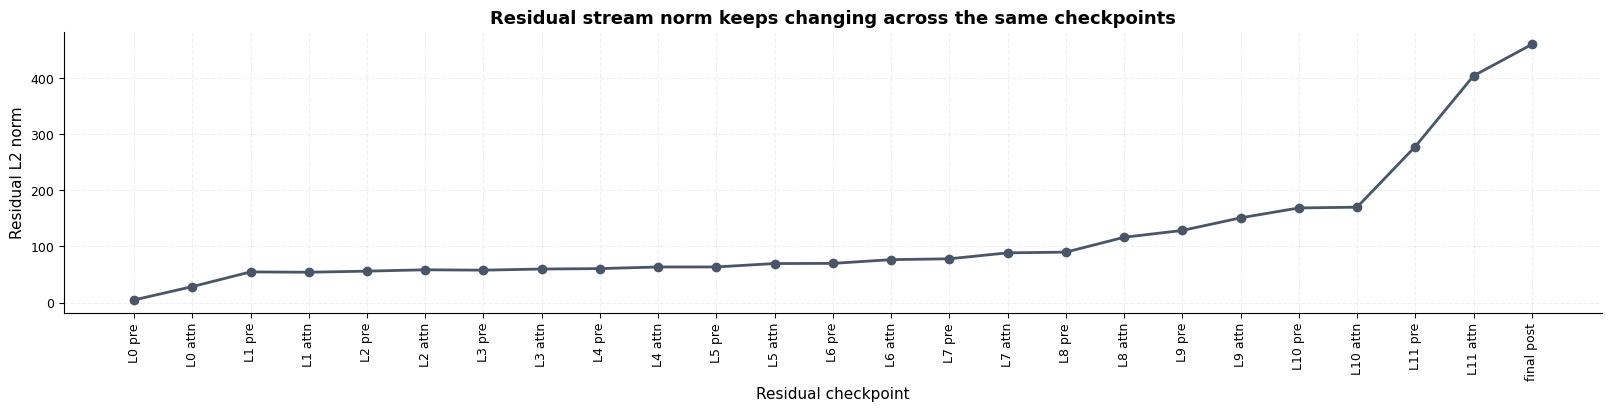

In [14]:
# We track the residual norm separately because state magnitude changes and
# answer quality changes are related but not identical.
plot_residual_norm(checkpoint_df)
plt.show()


In [15]:
# We call out the biggest norm jump so the reader knows where the state is
# being rewritten most aggressively.
biggest_norm_jump = checkpoint_df["residual_norm"].diff().abs().fillna(0).idxmax()
biggest_norm_label = checkpoint_df.loc[biggest_norm_jump, "label_short"]
biggest_norm_delta = checkpoint_df["residual_norm"].diff().abs().fillna(0).max()

display_takeaways(
    title="Reading the residual norm plot",
    what="The L2 norm of the accumulated residual stream at the final position across the same checkpoints.",
    change=(f"The largest checkpoint-to-checkpoint norm change lands at {biggest_norm_label}, with an absolute jump of {biggest_norm_delta:0.3f}."),
    why="The model can keep reshaping the state even after the answer starts to look better, which tells us confidence and state magnitude are not the same thing.",
    practice="For release diagnostics, norm changes can act as a quick triage signal for where a workflow-relevant behavior is being rewritten inside the network.",
)


### Reading the residual norm plot
- What we are looking at: The L2 norm of the accumulated residual stream at the final position across the same checkpoints.
- What changes here: The largest checkpoint-to-checkpoint norm change lands at L11 attn, with an absolute jump of 125.911.
- Why it matters: The model can keep reshaping the state even after the answer starts to look better, which tells us confidence and state magnitude are not the same thing.
- Why this matters in practice: For release diagnostics, norm changes can act as a quick triage signal for where a workflow-relevant behavior is being rewritten inside the network.

## 3. Which components start to push the answer upward?

The emergence plots tell us when the answer becomes visible. Direct logit attribution tells us which residual components are doing the pushing at the final position. This is a bridge from timeline to mechanism: not causal proof yet, but a disciplined way to turn the full network into a short list of suspects.


In [16]:
# We decompose the final residual stream into broad component groups so we can
# see which layers and which pathways contribute most to the target token.
resid_all, labels_all = cache.decompose_resid(layer=model.cfg.n_layers, mode="all", return_labels=True)
resid_attn, labels_attn = cache.decompose_resid(layer=model.cfg.n_layers, mode="attn", return_labels=True)
resid_mlp, labels_mlp = cache.decompose_resid(layer=model.cfg.n_layers, mode="mlp", return_labels=True)

# We also stack the attention-head results separately because those are the
# components we will inspect and test later.
head_results = cache.stack_head_results(layer=model.cfg.n_layers, return_labels=False)

dla_all_df = attrs_to_df(labels_all, cache.logit_attrs(resid_all, TARGET_ANSWER))
dla_attn_df = attrs_to_df(labels_attn, cache.logit_attrs(resid_attn, TARGET_ANSWER))
dla_mlp_df = attrs_to_df(labels_mlp, cache.logit_attrs(resid_mlp, TARGET_ANSWER))
head_attr_df = head_attrs_to_df(model, cache.logit_attrs(head_results, TARGET_ANSWER))

display(Markdown("### Top residual contributors"))
display(dla_all_df.head(10))
display(Markdown("### Top attention heads by direct logit attribution"))
display(head_attr_df.head(10))


### Top residual contributors

,component,logit_attr
0,9_mlp_out,4.1132
1,9_attn_out,4.1024
2,8_attn_out,3.6786
3,10_attn_out,1.3749
4,7_attn_out,1.2171
5,8_mlp_out,1.0243
6,10_mlp_out,0.7278
7,6_attn_out,0.6837
8,5_attn_out,0.6444
9,11_attn_out,0.3972


### Top attention heads by direct logit attribution

,layer,head,label,logit_attr
0,9,8,L9H8,3.5336
1,8,11,L8H11,2.7069
2,10,0,L10H0,1.2767
3,8,6,L8H6,0.8963
4,10,3,L10H3,0.8028
5,11,3,L11H3,0.6526
6,8,8,L8H8,0.6497
7,7,7,L7H7,0.5959
8,5,0,L5H0,0.3137
9,0,8,L0H8,0.3038


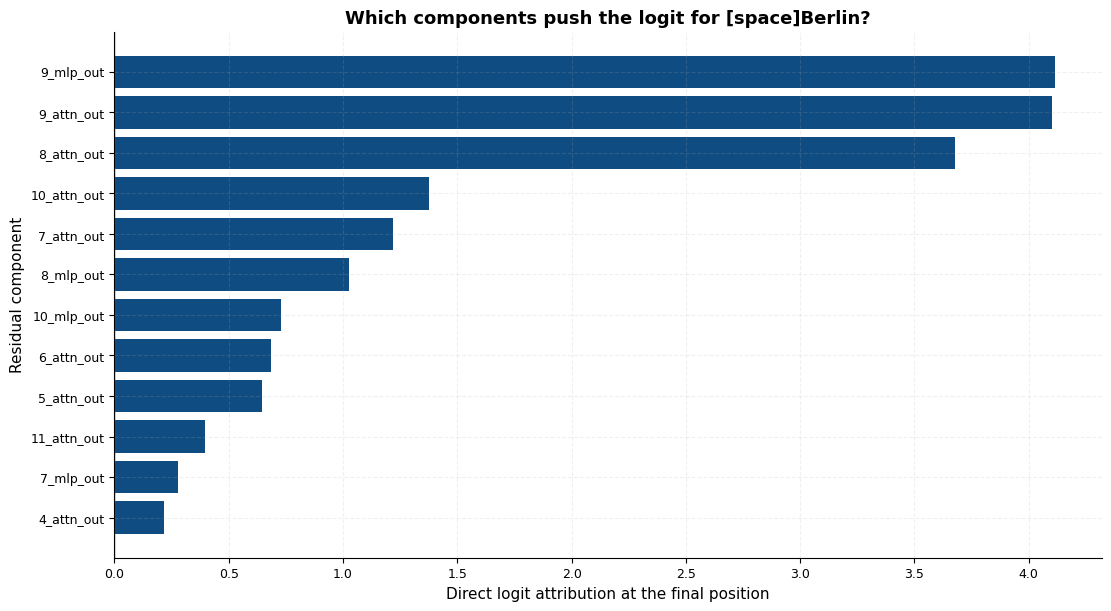

In [17]:
# We plot the largest direct-logit-attribution contributors so the likely
# mechanism is visible before we move to causal tests.
plot_component_attribution(dla_all_df, TARGET_ANSWER, top_n=TOP_COMPONENTS)
plt.show()


In [18]:
# We translate the attribution rankings into a compact hypothesis statement.
top_component = dla_all_df.iloc[0]
top_attention_head = head_attr_df.iloc[0]

display_takeaways(
    title="Reading the attribution view",
    what="Direct logit attribution scores for residual components and individual attention heads at the final position.",
    change=(f"The strongest overall component is {top_component['component']} with attribution {top_component['logit_attr']:0.3f}, and the strongest attention head is {top_attention_head['label']} with attribution {top_attention_head['logit_attr']:0.3f}."),
    why="This is our first concrete hypothesis about where the answer is being pushed upward inside the network.",
    practice="Attribution turns a large model into a short audit list, which is far more practical when teams need to explain or validate a behavior under delivery timelines.",
)


### Reading the attribution view
- What we are looking at: Direct logit attribution scores for residual components and individual attention heads at the final position.
- What changes here: The strongest overall component is 9_mlp_out with attribution 4.113, and the strongest attention head is L9H8 with attribution 3.534.
- Why it matters: This is our first concrete hypothesis about where the answer is being pushed upward inside the network.
- Why this matters in practice: Attribution turns a large model into a short audit list, which is far more practical when teams need to explain or validate a behavior under delivery timelines.

## 4. Do those heads read from the right places?

Attention patterns are still descriptive, but they help us sanity-check the hypothesis before we intervene. If the top heads are reading from tokens that plausibly support the answer, the story becomes more credible. If their routing looks arbitrary, we should be more skeptical before moving to patching.


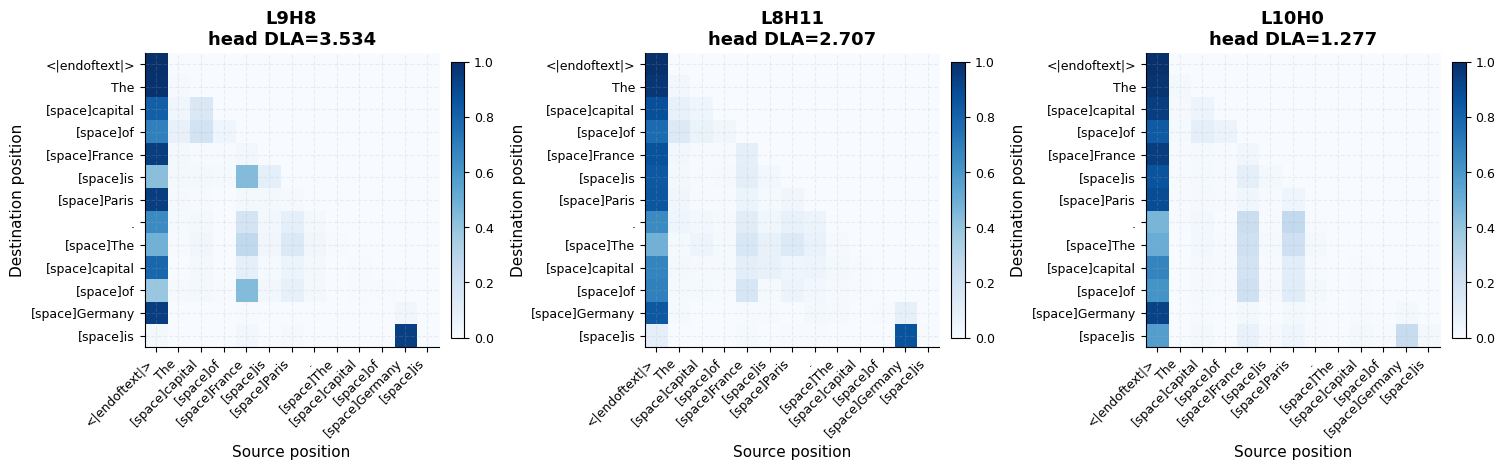

In [19]:
# We visualize the attention patterns of the top-scoring heads so we can see
# whether they appear to route information from plausible source tokens.
attention_heads_df = head_attr_df.head(HEADS_TO_VISUALIZE).copy()
plot_attention_heads(cache, attention_heads_df, str_tokens)
plt.show()


In [20]:
# We summarize the strongest head in plain language to connect the picture to
# the mechanistic hypothesis we will test next.
top_head_row = attention_heads_df.iloc[0]
top_pattern = cache["pattern", int(top_head_row["layer"])][int(top_head_row["head"])].detach().cpu().numpy()
top_last_query = top_pattern[-1]
top_source_idx = int(top_last_query.argmax())
top_source_token = visible_token(str_tokens[top_source_idx])
top_source_weight = float(top_last_query[top_source_idx])

display_takeaways(
    title="Reading the attention patterns",
    what="Static attention maps for the most attribution-heavy heads.",
    change=(f"For the top head {top_head_row['label']}, the final query position pays its largest attention weight to {top_source_token} with weight {top_source_weight:0.3f}."),
    why="When a candidate head attends to a token that plausibly supports the answer, the mechanistic story becomes more coherent before we even intervene causally.",
    practice="This kind of routing check is useful when someone asks whether a model behavior looks interpretable enough to trust, escalate, or investigate further.",
)


### Reading the attention patterns
- What we are looking at: Static attention maps for the most attribution-heavy heads.
- What changes here: For the top head L9H8, the final query position pays its largest attention weight to [space]Germany with weight 0.939.
- Why it matters: When a candidate head attends to a token that plausibly supports the answer, the mechanistic story becomes more coherent before we even intervene causally.
- Why this matters in practice: This kind of routing check is useful when someone asks whether a model behavior looks interpretable enough to trust, escalate, or investigate further.

## 5. Can the hypothesis survive a causal test?

Up to this point, we have a descriptive story: when the answer appears, which components score highly, and where the strongest heads are looking. Patching is where that story has to earn its keep. If the attribution story is meaningful, restoring activations in the same neighborhood should recover the clean behavior.


### Working hypothesis before intervention

If the earlier sections are pointing in the right direction, block-level recovery should concentrate in the same late layers that mattered in attribution, and head-level recovery should peak around the small set of candidate heads we just inspected. If that does not happen, we should treat the descriptive evidence above as incomplete.


In [21]:
# We build a clean-versus-corrupted pair with the same token length so the
# patching functions can swap activations position by position.
clean_tokens = model.to_tokens(CLEAN_PROMPT)
corrupted_tokens = model.to_tokens(CORRUPTED_PROMPT)
assert clean_tokens.shape == corrupted_tokens.shape, "Clean and corrupted prompts must have the same token length."

# We cache both runs because the patching utilities will repeatedly pull clean
# activations into the corrupted forward pass.
with torch.inference_mode():
    clean_logits, clean_cache = model.run_with_cache(clean_tokens)
    corrupted_logits, corrupted_cache = model.run_with_cache(corrupted_tokens)

metric = make_metric_for_answer(target_token_id, rival_token_id)
clean_score = metric(clean_logits).item()
corrupted_score = metric(corrupted_logits).item()

patch_setup_df = pd.DataFrame(
    [
        {"condition": "clean", "prompt": CLEAN_PROMPT, "metric": clean_score},
        {"condition": "corrupted", "prompt": CORRUPTED_PROMPT, "metric": corrupted_score},
    ]
)
display(patch_setup_df)


,condition,prompt,metric
0,clean,The capital of France is Paris. The capital of...,3.9636
1,corrupted,The capital of France is Paris. The capital of...,-8.0428


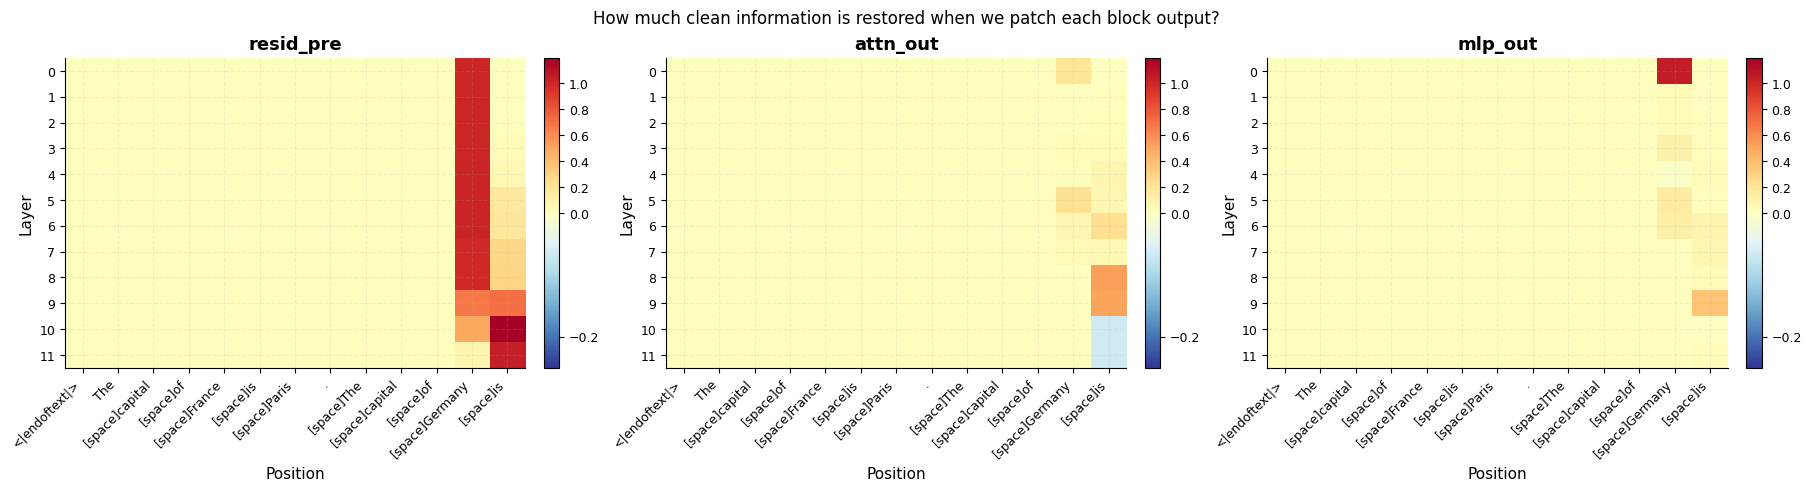

In [22]:
# We suppress the patching progress bars so the executed notebook stays clean
# when rendered on GitHub or reopened later.
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    block_patch = patching.get_act_patch_block_every(
        model=model,
        corrupted_tokens=corrupted_tokens,
        clean_cache=clean_cache,
        metric=metric,
    ).detach().cpu()

# We normalize the scores so 0 means corrupted behavior and 1 means full
# recovery of the clean behavior.
block_patch_normalized = normalize_patch_scores(
    block_patch,
    clean_score=clean_score,
    corrupted_score=corrupted_score,
)
plot_block_patching(block_patch_normalized, [visible_token(token) for token in model.to_str_tokens(CLEAN_PROMPT)])
plt.show()


In [23]:
# We locate the strongest patch site to summarize where the clean evidence is
# stored most causally.
patch_labels = ["resid_pre", "attn_out", "mlp_out"]
best_block_flat_idx = int(block_patch_normalized.argmax().item())
best_patch_type_idx, best_layer_idx, best_position_idx = np.unravel_index(best_block_flat_idx, block_patch_normalized.shape)
best_patch_type = patch_labels[best_patch_type_idx]
best_patch_token = visible_token(model.to_str_tokens(CLEAN_PROMPT)[best_position_idx])
best_patch_score = block_patch_normalized[best_patch_type_idx, best_layer_idx, best_position_idx].item()

display_takeaways(
    title="Reading the block patching heatmaps",
    what="Normalized recovery scores showing how much of the clean target-vs-rival behavior comes back when we patch each block output into the corrupted run.",
    change=(f"The strongest block-level recovery appears at {best_patch_type} in layer {best_layer_idx} at token position {best_patch_token}, with normalized recovery {best_patch_score:0.3f}."),
    why="This tells us where the clean evidence for the answer is stored in a causal sense, not just where the final logits happen to look favorable.",
    practice="For a business-critical workflow, patching points to the smallest part of the computation worth reviewing first when a model update changes behavior.",
)


### Reading the block patching heatmaps
- What we are looking at: Normalized recovery scores showing how much of the clean target-vs-rival behavior comes back when we patch each block output into the corrupted run.
- What changes here: The strongest block-level recovery appears at resid_pre in layer 10 at token position [space]is, with normalized recovery 1.192.
- Why it matters: This tells us where the clean evidence for the answer is stored in a causal sense, not just where the final logits happen to look favorable.
- Why this matters in practice: For a business-critical workflow, patching points to the smallest part of the computation worth reviewing first when a model update changes behavior.

,layer,head,label,score
0,9,8,L9H8,0.4767
1,8,11,L8H11,0.4330
2,10,0,L10H0,0.2407
3,5,1,L5H1,0.1478
4,6,7,L6H7,0.1390
5,8,5,L8H5,0.1290
6,7,6,L7H6,0.0998
7,6,10,L6H10,0.0751
8,0,1,L0H1,0.0686
9,10,10,L10H10,0.0682


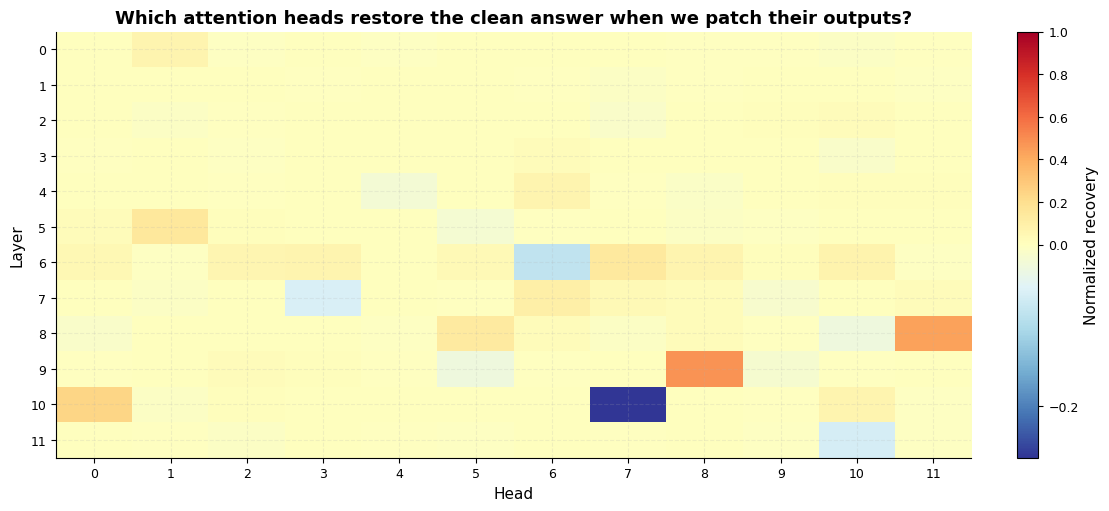

In [24]:
# We repeat the same idea at head resolution to find the attention heads that
# restore the answer most strongly.
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    head_patch_all = patching.get_act_patch_attn_head_all_pos_every(
        model=model,
        corrupted_tokens=corrupted_tokens,
        clean_cache=clean_cache,
        metric=metric,
    ).detach().cpu()

head_out_patch_normalized = normalize_patch_scores(
    head_patch_all[0],
    clean_score=clean_score,
    corrupted_score=corrupted_score,
)
head_patch_df = head_scores_to_df(head_out_patch_normalized)

display(head_patch_df.head(12))
plot_head_patching(head_out_patch_normalized)
plt.show()


In [25]:
# We summarize the best head-level recovery so the next ablation section has a
# clear set of candidates to test.
top_patch_head = head_patch_df.iloc[0]

display_takeaways(
    title="Reading the head patching heatmap",
    what="Normalized recovery after patching each attention head's output into the corrupted run.",
    change=(f"The strongest head-level recovery comes from {top_patch_head['label']} with normalized recovery {top_patch_head['score']:0.3f}."),
    why="If a small number of heads restore most of the clean behavior, we have a much tighter mechanistic hypothesis than saying the whole model somehow did it.",
    practice="This gives delivery or review teams a concrete shortlist of components to monitor after a model change rather than a vague suspicion that the entire model shifted.",
)


### Reading the head patching heatmap
- What we are looking at: Normalized recovery after patching each attention head's output into the corrupted run.
- What changes here: The strongest head-level recovery comes from L9H8 with normalized recovery 0.477.
- Why it matters: If a small number of heads restore most of the clean behavior, we have a much tighter mechanistic hypothesis than saying the whole model somehow did it.
- Why this matters in practice: This gives delivery or review teams a concrete shortlist of components to monitor after a model change rather than a vague suspicion that the entire model shifted.

### What would count as strong causal evidence?

Patching tells us that a component can carry the behavior. Ablation asks the stricter question of necessity. The strongest case is when the same small set of heads both restores the answer under patching and damages it when removed from the clean run.


## 6. What fails when we remove the candidate heads?

Patching tells us which heads can bring the clean behavior back. Ablation asks the complementary question: if we remove those same heads on the clean prompt, how much of the answer falls apart? This is the cleanest way to separate an active mechanism from a correlated bystander.


In [26]:
# We ablate the strongest patched heads on the clean prompt to see which ones
# are actually necessary for the behavior we care about.
candidate_heads_df = head_patch_df.head(HEADS_TO_ABLATE).copy()
with torch.inference_mode():
    baseline_metric = metric(model(clean_tokens)).item()

ablation_rows = []
for row in candidate_heads_df.itertuples(index=False):
    ablation_rows.append(
        ablate_single_head_and_score(
            model=model,
            tokens=clean_tokens,
            layer=int(row.layer),
            head=int(row.head),
            metric_fn=metric,
            baseline_score=baseline_metric,
        )
    )

ablation_df = pd.DataFrame(ablation_rows).sort_values("delta").reset_index(drop=True)
display(ablation_df)


,layer,head,label,baseline_score,ablated_score,delta
0,8,11,L8H11,3.9636,2.5284,-1.4352
1,10,0,L10H0,3.9636,3.5208,-0.4429
2,9,8,L9H8,3.9636,3.6284,-0.3353
3,5,1,L5H1,3.9636,3.8242,-0.1394
4,6,7,L6H7,3.9636,3.8376,-0.1260
5,8,5,L8H5,3.9636,3.8987,-0.0649


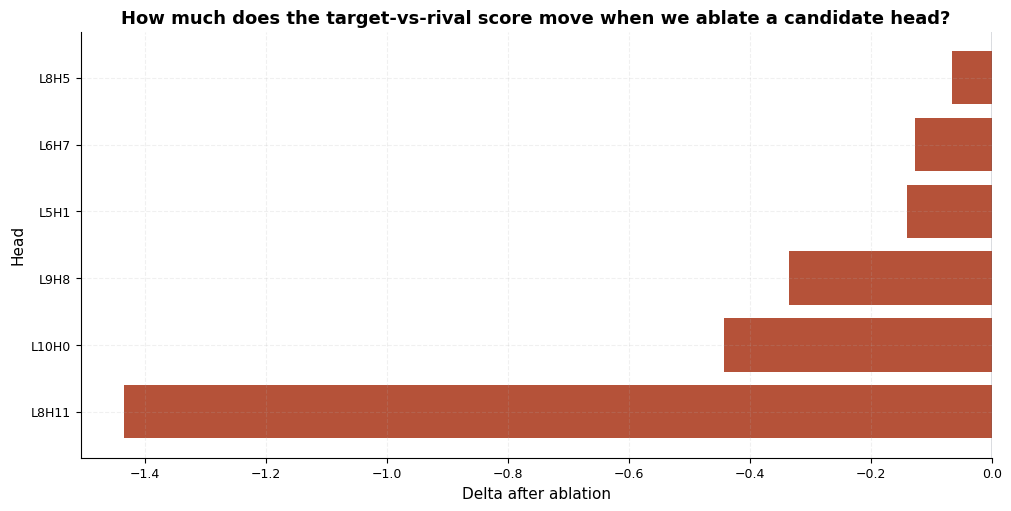

In [27]:
# We plot the ablation deltas so the most important heads stand out visually.
plot_ablation_effects(ablation_df)
plt.show()


In [28]:
# We call out the most damaging ablation because that is the cleanest causal
# evidence in the notebook.
most_harmful_head = ablation_df.iloc[0]

display_takeaways(
    title="Reading the ablation chart",
    what="The change in the target-minus-rival score after zeroing out each candidate head on the clean prompt.",
    change=(f"Ablating {most_harmful_head['label']} produces the largest drop, with delta {most_harmful_head['delta']:0.3f}."),
    why="This is the strongest evidence in the notebook that a small set of heads are not just correlated with the answer. They matter to producing it.",
    practice="Ablation helps separate components that are genuinely carrying workflow-relevant behavior from components that merely happen to light up at the same time.",
)


### Reading the ablation chart
- What we are looking at: The change in the target-minus-rival score after zeroing out each candidate head on the clean prompt.
- What changes here: Ablating L8H11 produces the largest drop, with delta -1.435.
- Why it matters: This is the strongest evidence in the notebook that a small set of heads are not just correlated with the answer. They matter to producing it.
- Why this matters in practice: Ablation helps separate components that are genuinely carrying workflow-relevant behavior from components that merely happen to light up at the same time.

## 7. What story best fits the evidence?

We now have three layers of evidence. The checkpoint plots tell us when the answer forms. Attribution and attention inspection tell us where to look. Patching and ablation tell us which parts of that story survive intervention. The goal here is not to claim a universal theorem about transformers; it is to end with a mechanism we can describe, defend, and reuse as a debugging hypothesis.


In [29]:
# We pull the main evidence into one final summary block so the notebook ends
# with an interpretable mechanism story rather than a scattered list of plots.
final_summary_lines = [
    "### Final summary",
    "The evidence fits a staged story rather than a single late surprise.",
    "#### Evidence chain",
    f"- Temporal: {visible_token(TARGET_ANSWER)} first beats {visible_token(RIVAL_ANSWER)} at {first_target_beats_rival} and reaches rank 1 at {first_target_top}.",
    f"- Directional: the strongest overall residual contributor is {top_component['component']} ({top_component['logit_attr']:0.3f}), while {top_attention_head['label']} is the strongest attention head by attribution ({top_attention_head['logit_attr']:0.3f}).",
    f"- Causal recovery: the strongest block patch site is {best_patch_type} in layer {best_layer_idx} on {best_patch_token} ({best_patch_score:0.3f}), and the strongest head patch site is {top_patch_head['label']} ({top_patch_head['score']:0.3f}).",
    f"- Causal necessity: ablating {most_harmful_head['label']} causes the largest drop in the target-vs-rival score ({most_harmful_head['delta']:0.3f}).",
    "#### Interpretation",
    f"- A compact explanation is that late-layer components, including {top_attention_head['label']}, help route context so {visible_token(TARGET_ANSWER)} overtakes {visible_token(RIVAL_ANSWER)} at the final position.",
    "#### Practical reading",
    "- If a later prompt change, fine-tune, or model upgrade breaks this behavior, the same checkpoints, patch sites, and heads become the first places worth inspecting.",
]
display(Markdown("\n".join(final_summary_lines)))


### Final summary
The evidence fits a staged story rather than a single late surprise.
#### Evidence chain
- Temporal: [space]Berlin first beats [space]Paris at L0 pre and reaches rank 1 at L8 attn.
- Directional: the strongest overall residual contributor is 9_mlp_out (4.113), while L9H8 is the strongest attention head by attribution (3.534).
- Causal recovery: the strongest block patch site is resid_pre in layer 10 on [space]is (1.192), and the strongest head patch site is L9H8 (0.477).
- Causal necessity: ablating L8H11 causes the largest drop in the target-vs-rival score (-1.435).
#### Interpretation
- A compact explanation is that late-layer components, including L9H8, help route context so [space]Berlin overtakes [space]Paris at the final position.
#### Practical reading
- If a later prompt change, fine-tune, or model upgrade breaks this behavior, the same checkpoints, patch sites, and heads become the first places worth inspecting.

## Why this kind of analysis matters once models enter real workflows

- Release triage: When a model, prompt, or retrieval change breaks a workflow, the same sequence of plots helps narrow the failure from “the model changed” to “this stage or head stopped carrying the right evidence.”
- Evidence for stakeholders: Product owners, review leads, and risk partners usually need more than a benchmark delta. Mechanistic traces provide a clearer explanation of what changed and where.
- Targeted validation: If a critical behavior depends on a small number of components or late-stage patches, teams can focus red-team prompts and regression checks on that part of the computation.
- Change governance: A model upgrade can preserve surface accuracy while shifting to a different internal route. Knowing that route changed is useful when robustness matters more than a one-off success rate.
- Operational trust: Trust is easier to defend when it is tied to inspected behavior, causal tests, and known failure points rather than a vague sense that the model “seems fine.”

This notebook stays intentionally local. That is a strength, not a weakness. In practice, teams usually investigate one fragile behavior at a time, build a reusable debugging pattern, and then decide where deeper interpretability work is worth the effort.


## Appendix: optional MLP / neuron drill-down

The main story above is already complete. If we want to keep digging, we can decompose the residual stream more finely and inspect which MLP outputs contribute to the target token.


In [30]:
# We keep the appendix optional so the main story stays compact, but we still
# expose a deeper residual decomposition for anyone who wants to inspect MLP
# components or neurons in more detail.
try:
    full_resid, full_labels = cache.get_full_resid_decomposition(layer=model.cfg.n_layers, return_labels=True)
    full_attrs = cache.logit_attrs(full_resid, TARGET_ANSWER)
    full_df = attrs_to_df(full_labels, full_attrs)
    display(full_df.head(25))
except Exception as exc:
    print("Optional neuron-level drill-down was skipped.")
    print("Reason:", repr(exc))


,component,logit_attr
0,L9H8,3.5336
1,L8H11,2.7069
2,L9N1409,2.3655
3,L10H0,1.2767
4,L9N2649,1.0650
5,L8H6,0.8963
6,bias,0.8877
7,L10H3,0.8028
8,L11H3,0.6526
9,L8H8,0.6497
